# 02 — Forecasting & feature importance
**Goal:** forecast GDP growth, compare models honestly on a small (~50-quarter) sample,
and answer *which factor contributes most* — then test whether that answer survives the
2011-12 → 2022-23 base-year change.

Design choices driven by EDA:
- Model the **growth/YoY** forms (stationary), not levels.
- Features are the EDA-pruned set (collinear levels + exact-combo composites removed).
- Validation is **time-aware** (expanding window / fixed holdout) — never random k-fold,
  which would leak the future.
- With ~50 rows we lean on **regularized** models and read any single importance ranking
  as suggestive, cross-checked across methods.

## 0 · Setup & modelling frame

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi":110, "savefig.dpi":150, "savefig.bbox":"tight",
                     "axes.titleweight":"bold"})
BLUE, RED, GREEN, GREY = "#2c7fb8", "#d1495b", "#2a9d8f", "#9aa0a6"

import os
from pathlib import Path

CANDIDATES = [
    os.environ.get("GDP_PROJECT", ""),                       # 1) env var, if set
    *[str(p) for p in [Path.cwd(), *Path.cwd().parents]],    # 2) walk up from cwd
    r"C:\Users\asus\Projects\GDP",                           # 3) known local fallback
]
PROJECT = next(
    (Path(c).expanduser().resolve() for c in CANDIDATES
     if c and (Path(c).expanduser() / "data" / "processed").is_dir()),
    None,
)
if PROJECT is None:
    raise FileNotFoundError(f"Project root not found. cwd={Path.cwd()}")
print("project:", PROJECT)

df = pd.read_csv(PROJECT/"data"/"processed"/"composite_master_quarterly.csv")
FIGS = PROJECT/"outputs"/"figures"; FIGS.mkdir(parents=True, exist_ok=True)
FCST = PROJECT/"outputs"/"forecasts"; FCST.mkdir(parents=True, exist_ok=True)

TARGET = "GDP_growth"   # continuous spliced series (old 2011-12 + new 2022-23 tail)
FEATURES = ["FiscalDeficit_pct_GDP","Repo_QtrAvg","CPI_Inflation","IIP_growth",
            "INR_USD","INR_USD_vol","Brent_USD","GFCF_YoY","Exports_YoY","Imports_YoY",
            "M3_level_YoY","CrudeINR_YoY","InvestmentRate","TradeOpenness",
            "GDP_growth_lag1","GDP_growth_lag4"]
FEATURES = [c for c in FEATURES if c in df.columns]

# keep the manifest honest: role=feature rows must equal the model's FEATURES
_man = pd.read_csv(PROJECT/"data"/"processed"/"feature_manifest.csv")
_declared = set(_man.loc[_man["role"]=="feature", "column"])
assert _declared == set(FEATURES), f"manifest≠model: {_declared ^ set(FEATURES)}"

# --- separate genuine external drivers from GDP's own accounting components ---
# GDP = PFCE + GFCE + GFCF + (Exports - Imports) + ... , so the items below are
# PIECES of GDP, not external causes. Keeping them as "drivers" would be circular.
GDP_COMPONENTS   = ["GFCF_YoY", "Exports_YoY", "Imports_YoY", "InvestmentRate", "TradeOpenness"]
AR_LAGS          = ["GDP_growth_lag1", "GDP_growth_lag4"]          # target's own past
EXTERNAL_DRIVERS = [f for f in FEATURES if f not in GDP_COMPONENTS + AR_LAGS]
print("External drivers:", EXTERNAL_DRIVERS)
print("GDP components:", GDP_COMPONENTS)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



project: C:\Users\asus\Projects\GDP
External drivers: ['FiscalDeficit_pct_GDP', 'Repo_QtrAvg', 'CPI_Inflation', 'IIP_growth', 'INR_USD', 'INR_USD_vol', 'Brent_USD', 'M3_level_YoY', 'CrudeINR_YoY']
GDP components: ['GFCF_YoY', 'Exports_YoY', 'Imports_YoY', 'InvestmentRate', 'TradeOpenness']


In [3]:
# Usable modelling rows = target present AND all features present.
work = df[["FY_Quarter", TARGET] + FEATURES].copy()
work = work.dropna().reset_index(drop=True)
y = work[TARGET].astype(float)
X = work[FEATURES].astype(float)
labels = work["FY_Quarter"].values
print(f"Modelling rows: {len(work)}  ({labels[0]} -> {labels[-1]})")

# Time-aware holdout: last 8 quarters (2 years) for the final scoreboard.
H = 8
Xtr, Xte = X.iloc[:-H], X.iloc[-H:]
ytr, yte = y.iloc[:-H], y.iloc[-H:]
lab_te = labels[-H:]
print(f"train {len(Xtr)}  |  holdout {len(Xte)}  ({lab_te[0]} -> {lab_te[-1]})")

Modelling rows: 50  (2013-14 Q1 -> 2025-26 Q2)
train 42  |  holdout 8  (2023-24 Q3 -> 2025-26 Q2)


## 1 · Baselines
Any model must beat these. **Naive** = last quarter's growth; **Seasonal naive** =
same quarter last year. On macro YoY data these are surprisingly hard to beat.

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
scores = {}

# naive: predict y_{t-1}; seasonal naive: predict y_{t-4}. Build from full y so the
# holdout predictions use real (not modelled) lagged actuals.
naive_pred    = y.shift(1).iloc[-H:]
seasonal_pred = y.shift(4).iloc[-H:]
scores["Naive (t-1)"]        = (rmse(yte, naive_pred),    mean_absolute_error(yte, naive_pred))
scores["Seasonal naive (t-4)"] = (rmse(yte, seasonal_pred), mean_absolute_error(yte, seasonal_pred))
print(pd.DataFrame(scores, index=["RMSE","MAE"]).T.round(3))

                       RMSE    MAE
Naive (t-1)           0.970  0.836
Seasonal naive (t-4)  2.896  2.629


## 2 · SARIMA / SARIMAX
SARIMA models GDP growth from its own past; SARIMAX adds a few exogenous drivers.
We use integer positions (no calendar frequency) to avoid index-frequency pitfalls.
`d=0` because EDA showed the growth series is already stationary.

In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_sarimax(endog_tr, endog_te, exog_tr=None, exog_te=None, order=(2,0,1),
                seasonal=(1,0,0,4)):
    m = SARIMAX(endog_tr.values, exog=None if exog_tr is None else exog_tr.values,
                order=order, seasonal_order=seasonal,
                enforce_stationarity=False, enforce_invertibility=False)
    r = m.fit(disp=False)
    fc = r.forecast(steps=len(endog_te),
                    exog=None if exog_te is None else exog_te.values)
    return np.asarray(fc)

try:
    p = fit_sarimax(ytr, yte)
    scores["SARIMA(2,0,1)(1,0,0)4"] = (rmse(yte, p), mean_absolute_error(yte, p))
except Exception as e:
    print("SARIMA failed:", e)

# SARIMAX with a small curated exog set (keep it lean for ~50 obs).
exog_small = ["IIP_growth","Repo_QtrAvg","M3_level_YoY","GDP_growth_lag1"]
try:
    p = fit_sarimax(ytr, yte, Xtr[exog_small], Xte[exog_small], order=(1,0,0), seasonal=(0,0,0,0))
    scores["SARIMAX(+4 exog)"] = (rmse(yte, p), mean_absolute_error(yte, p))
except Exception as e:
    print("SARIMAX failed:", e)
print(pd.DataFrame(scores, index=["RMSE","MAE"]).T.round(3))

                        RMSE    MAE
Naive (t-1)            0.970  0.836
Seasonal naive (t-4)   2.896  2.629
SARIMA(2,0,1)(1,0,0)4  3.501  3.466
SARIMAX(+4 exog)       1.194  0.897


## 3 · Regularized linear + tree ensembles
Ridge / LassoCV / ElasticNetCV (scaled) and shallow RandomForest / GradientBoosting.
Lasso doubles as feature selection. All scored on the same holdout for a fair table.

> **Read the scoreboard honestly.** On already-YoY macro data over ~50 quarters, the
> random-walk **naive (t-1)** baseline is very hard to beat — that's a known result, not a
> failure of the models. The regularized models land *close* to it; their real payoff is
> **interpretability** (Section 5), letting us name the drivers a naive model can't.

In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
models = {
    "Ridge":        make_pipeline(StandardScaler(), Ridge(alpha=5.0)),
    "LassoCV":      make_pipeline(StandardScaler(), LassoCV(cv=tscv, max_iter=50000)),
    "ElasticNetCV": make_pipeline(StandardScaler(), ElasticNetCV(cv=tscv, max_iter=50000)),
    "RandomForest": RandomForestRegressor(n_estimators=400, max_depth=4,
                                          min_samples_leaf=3, random_state=0),
    "GradBoost":    GradientBoostingRegressor(n_estimators=300, max_depth=2,
                                              learning_rate=0.03, subsample=0.8, random_state=0),
}
fitted = {}
for name, mdl in models.items():
    mdl.fit(Xtr, ytr)
    pred = mdl.predict(Xte)
    scores[name] = (rmse(yte, pred), mean_absolute_error(yte, pred))
    fitted[name] = mdl

board = pd.DataFrame(scores, index=["RMSE","MAE"]).T.sort_values("RMSE")
print(board.round(3).to_string())

                        RMSE    MAE
Naive (t-1)            0.970  0.836
Ridge                  1.027  0.954
ElasticNetCV           1.072  0.935
LassoCV                1.075  0.962
SARIMAX(+4 exog)       1.194  0.897
RandomForest           1.562  1.399
GradBoost              1.805  1.519
Seasonal naive (t-4)   2.896  2.629
SARIMA(2,0,1)(1,0,0)4  3.501  3.466


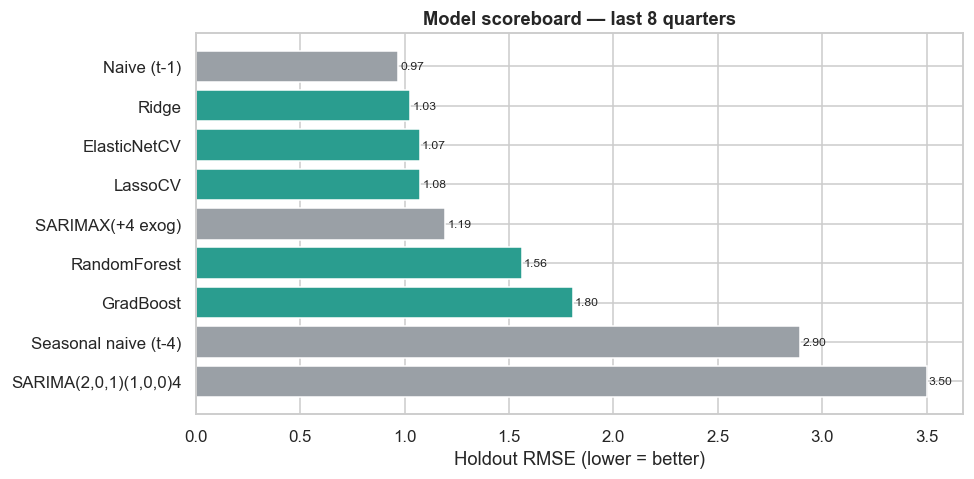

Best overall: Naive (t-1) | Best ML model (used downstream): Ridge


In [7]:
# Scoreboard figure
fig, ax = plt.subplots(figsize=(9, 4.5))
order = board.index[::-1]
ax.barh(order, board.loc[order, "RMSE"],
        color=[GREEN if m in fitted else GREY for m in order])
ax.set_xlabel("Holdout RMSE (lower = better)")
ax.set_title("Model scoreboard — last 8 quarters")
for i, m in enumerate(order):
    ax.text(board.loc[m,"RMSE"]+.01, i, f'{board.loc[m,"RMSE"]:.2f}', va="center", fontsize=8)
fig.savefig(FIGS/"02a_model_scoreboard.png"); plt.show()

BEST = board.loc[board.index.isin(models.keys())].index[0]
print("Best overall:", board.index[0], "| Best ML model (used downstream):", BEST)

## 4 · Expanding-window CV (robustness)
A single holdout can be lucky. Here each ML model is re-scored over 5 expanding folds so
the ranking isn't an artefact of one split.

In [8]:
cv_rmse = {}
for name, mdl in models.items():
    errs = []
    for tr_idx, te_idx in tscv.split(X):
        mdl.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        errs.append(rmse(y.iloc[te_idx], mdl.predict(X.iloc[te_idx])))
    cv_rmse[name] = np.mean(errs)
cv = pd.Series(cv_rmse, name="CV_RMSE").sort_values()
print(cv.round(3).to_string())

Ridge           3.314
ElasticNetCV    3.655
RandomForest    3.908
GradBoost       4.406
LassoCV         4.476


## 5 · Which factor contributes most?
Three independent lenses — they rarely agree perfectly, so we trust features that rank
high across all three: **Lasso coefficients** (standardized), **permutation importance**
(model-agnostic), and **SHAP** (per-observation attribution).

In [9]:
# (a) Lasso standardized coefficients
lasso = make_pipeline(StandardScaler(), LassoCV(cv=tscv, max_iter=50000)).fit(X, y)
coef = pd.Series(lasso[-1].coef_, index=FEATURES)
nz = coef[coef.abs() > 1e-6].sort_values(key=np.abs, ascending=False)
print("Lasso kept", len(nz), "of", len(FEATURES), "features:")
print(nz.round(3).to_string())

Lasso kept 13 of 16 features:
IIP_growth               3.153
GFCF_YoY                 1.835
FiscalDeficit_pct_GDP   -1.032
CrudeINR_YoY            -0.807
Imports_YoY              0.603
GDP_growth_lag1          0.572
CPI_Inflation            0.396
Brent_USD                0.332
INR_USD                  0.274
InvestmentRate          -0.259
INR_USD_vol              0.055
GDP_growth_lag4          0.030
M3_level_YoY             0.027


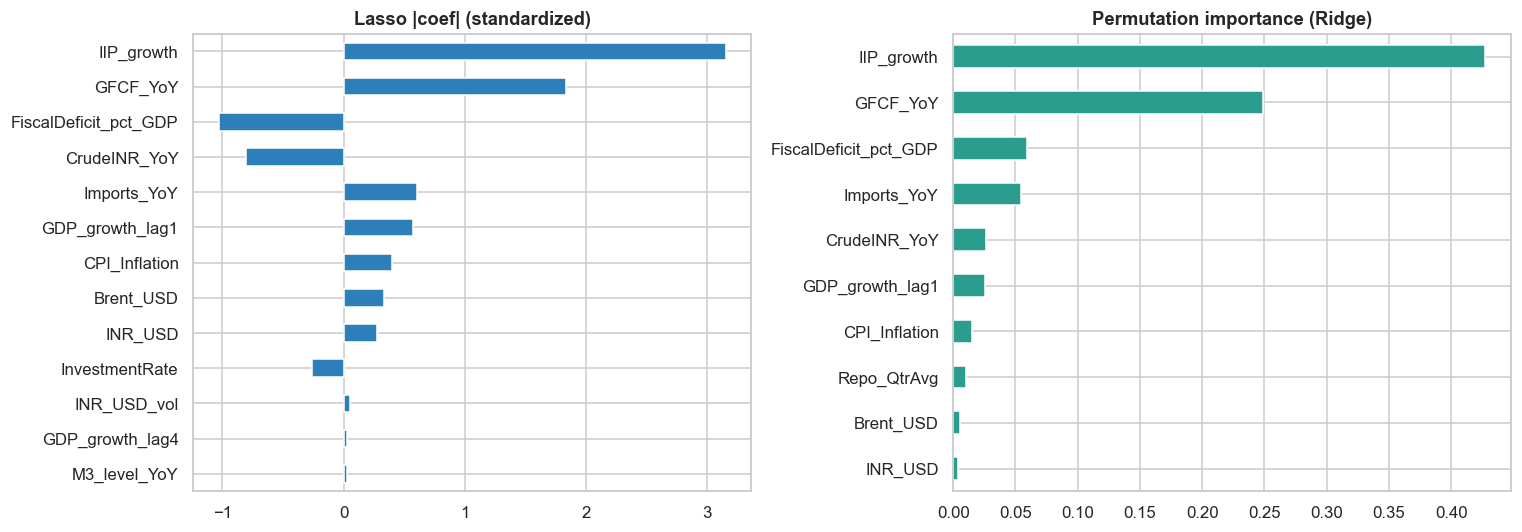

In [10]:
# (b) Permutation importance on the best model (refit on full data)
from sklearn.inspection import permutation_importance
best_model = models[BEST].fit(X, y)
pi = permutation_importance(best_model, X, y, n_repeats=30, random_state=0)
perm = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
nz.iloc[::-1].plot.barh(ax=ax[0], color=BLUE); ax[0].set_title("Lasso |coef| (standardized)")
perm.head(10).iloc[::-1].plot.barh(ax=ax[1], color=GREEN)
ax[1].set_title(f"Permutation importance ({BEST})")
fig.tight_layout(); fig.savefig(FIGS/"02b_importance.png"); plt.show()

In [ ]:
# (c) SHAP — works best on the tree model; wrapped so it never breaks the run.
try:
    import shap
    tree = GradientBoostingRegressor(n_estimators=300, max_depth=2, learning_rate=0.03,
                                     subsample=0.8, random_state=0).fit(X, y)
    expl = shap.TreeExplainer(tree)
    sv = expl.shap_values(X)
    shap.summary_plot(sv, X, show=False, plot_size=(9,5))
    plt.tight_layout(); plt.savefig(FIGS/"02c_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    shap_imp = pd.Series(np.abs(sv).mean(0), index=FEATURES).sort_values(ascending=False)
    HAS_SHAP = True
    print("Top SHAP drivers:"); print(shap_imp.head(8).round(3).to_string())
except Exception as e:
    print("SHAP skipped (install `shap` to enable the 3rd lens):", e)
    shap_imp, HAS_SHAP = None, False

SHAP skipped (install `shap` to enable the 3rd lens): No module named 'shap'


In [12]:
# Consensus: average rank across the lenses that actually ran (no double-counting).
lenses = {
    "lasso": nz.reindex(FEATURES).abs().rank(ascending=False),
    "perm":  perm.reindex(FEATURES).rank(ascending=False),
}
if HAS_SHAP:
    lenses["shap"] = shap_imp.reindex(FEATURES).rank(ascending=False)
ranks = pd.DataFrame(lenses)
consensus = ranks.mean(axis=1).sort_values()
ext = consensus[consensus.index.isin(EXTERNAL_DRIVERS)]   # exclude GDP's own components
print(f"CONSENSUS top EXTERNAL drivers (avg rank across {len(lenses)} methods: {', '.join(lenses)}):")
print(ext.head(6).round(2).to_string())
print("\nNote: GDP components (GFCF, Exports, Imports, etc.) are not listed here because")
print("they are parts of GDP by accounting identity; their role is shown later.")

CONSENSUS top EXTERNAL drivers (avg rank across 2 methods: lasso, perm):
IIP_growth               1.0
FiscalDeficit_pct_GDP    3.0
CrudeINR_YoY             4.5
CPI_Inflation            7.0
Repo_QtrAvg              8.0
Brent_USD                8.5

Note: GDP components (GFCF, Exports, Imports, etc.) are not listed here because
they are parts of GDP by accounting identity; their role is shown later.


## 6 · Forward forecast — FY 2026-27 Q1 & Q2
**Why SARIMAX here, not the regression models above?** To predict a *future* quarter with a
regression model you need that quarter's CPI/IIP/repo/etc. — but for 2026-27 Q1 (Apr-Jun
2026) and Q2 those values don't exist yet. A **SARIMAX** driven only by GDP's own past plus a
*deterministic* COVID dummy needs no *unknown* future inputs (the dummy is a known 0 ahead),
so it's the correct tool for a genuine out-of-sample forecast. We forecast the **continuous spliced `GDP_growth` series** (old
2011-12 base + new 2022-23 tail), which runs unbroken through 2025-26 Q4.

In [13]:
# Full continuous target, chronological, through 2025-26 Q4 (drops the empty horizon rows).
key = lambda s: s.map(lambda q: int(q[:4])*4 + int(q[-1]))
ser = df.sort_values("FY_Quarter", key=key)[["FY_Quarter", TARGET, "COVID"]].dropna(subset=[TARGET])
y_full = ser[TARGET].to_numpy()
exog   = ser[["COVID"]].to_numpy()        # known dummy: 1 in 2020-21, 0 elsewhere & in future
hist_labels = ser["FY_Quarter"].tolist()
print(f"Training the forecaster on {len(y_full)} quarters: {hist_labels[0]} -> {hist_labels[-1]}")

# COVID is passed as an exogenous dummy so the 2020-21 swings don't distort the AR/MA
# dynamics. It's 0 for 2026-27, so there's no 'future data' problem.
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
best = None
for order in itertools.product([0,1,2],[0],[0,1,2]):
    for seas in [(0,0,0,0),(1,0,0,4)]:
        try:
            r = SARIMAX(y_full, exog=exog, order=order, seasonal_order=seas,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            if best is None or r.aic < best[0]:
                best = (r.aic, order, seas, r)
        except Exception:
            pass
aic, order, seas, res = best
print(f"Best SARIMAX by AIC: order={order} seasonal={seas}  (AIC={aic:.1f})")

Training the forecaster on 56 quarters: 2012-13 Q1 -> 2025-26 Q4


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best SARIMAX by AIC: order=(2, 0, 0) seasonal=(1, 0, 0, 4)  (AIC=281.8)


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


FY_Quarter  GDP_growth_forecast  lo_80  hi_80
2026-27 Q1                 7.07   2.37  11.77
2026-27 Q2                 6.14  -1.32  13.60


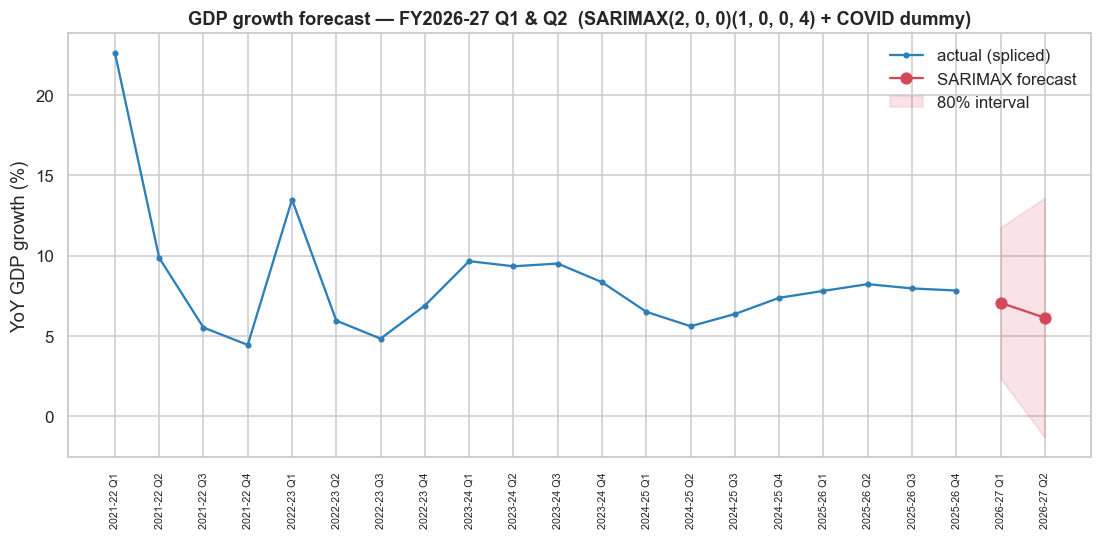

In [14]:
# Forecast the next 2 quarters (COVID dummy = 0 ahead) with an 80% interval.
fut_exog = np.array([[0],[0]])
fc = res.get_forecast(steps=2, exog=fut_exog)
mean = fc.predicted_mean
ci = fc.conf_int(alpha=0.20)
fut_labels = ["2026-27 Q1", "2026-27 Q2"]
out = pd.DataFrame({"FY_Quarter": fut_labels,
                    "GDP_growth_forecast": np.round(mean, 2),
                    "lo_80": np.round(ci[:,0], 2), "hi_80": np.round(ci[:,1], 2)})
out.to_csv(FCST/"gdp_forecast_FY2026_27.csv", index=False)
print(out.to_string(index=False))

show = 20
h_idx = range(len(y_full)); f_idx = range(len(y_full), len(y_full)+2)
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(list(h_idx)[-show:], y_full[-show:], "-o", color=BLUE, ms=3, label="actual (spliced)")
ax.plot(f_idx, mean, "-o", color=RED, ms=7, label="SARIMAX forecast")
ax.fill_between(f_idx, ci[:,0], ci[:,1], color=RED, alpha=0.15, label="80% interval")
labs = hist_labels[-show:] + fut_labels
pos = list(h_idx)[-show:] + list(f_idx)
ax.set_xticks(pos); ax.set_xticklabels(labs, rotation=90, fontsize=7)
ax.set_ylabel("YoY GDP growth (%)"); ax.legend(frameon=False)
ax.set_title(f"GDP growth forecast — FY2026-27 Q1 & Q2  (SARIMAX{order}{seas} + COVID dummy)")
fig.savefig(FIGS/"02d_forecast.png"); plt.show()

## 7 · Base-year sensitivity — does the answer change?
We repeat the importance analysis using the **new 2022-23-base** target over its short
overlap. With only ~10 points this is *directional*, not definitive — but if the top
drivers reshuffle, that's a finding worth reporting: the story of "what drives GDP"
is partly an artefact of which base year you measure it in.

Overlap rows (both bases present): 10  -> directional, not definitive

Spearman rank-corr between old/new importance orderings: -0.27
                       old_base  new_base
Imports_YoY               0.736     0.147
M3_level_YoY              0.669     0.324
FiscalDeficit_pct_GDP     0.650     0.155
GFCF_YoY                  0.639     0.038
GDP_growth_lag1           0.586     0.402
IIP_growth                0.572     0.409
Exports_YoY               0.530     0.507
CrudeINR_YoY              0.409     0.352
TradeOpenness             0.307     0.258
INR_USD                   0.294     0.347


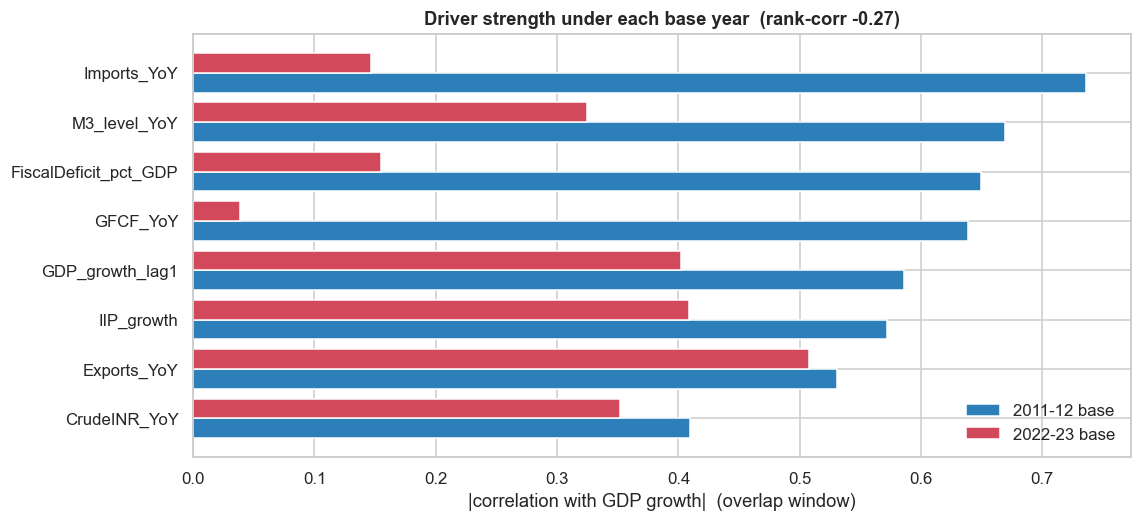

In [15]:
# Like-for-like on the OVERLAP window only, so old vs new differ by BASE, not by sample.
# Lasso on ~10 rows collapses to zero (too few obs for 16 features), so we use |corr|,
# which is estimable at small n, as the importance proxy for this comparison.
ov_mask = df["GDP_growth_old"].notna() & df["GDP_growth_new"].notna()           & df[FEATURES].notna().all(axis=1)
ov = df.loc[ov_mask]
print(f"Overlap rows (both bases present): {len(ov)}  -> directional, not definitive")

imp_old = ov[FEATURES].corrwith(ov["GDP_growth_old"]).abs()
imp_new = ov[FEATURES].corrwith(ov["GDP_growth_new"]).abs()
cmp = pd.DataFrame({"old_base": imp_old, "new_base": imp_new}).sort_values("old_base", ascending=False)
# rank-correlation between the two orderings = "how stable is the story across bases?"
from scipy.stats import spearmanr
rho = spearmanr(cmp["old_base"], cmp["new_base"]).statistic
print(f"\nSpearman rank-corr between old/new importance orderings: {rho:.2f}")
print(cmp.round(3).head(10).to_string())

fig, ax = plt.subplots(figsize=(11,5))
top = cmp.head(8).iloc[::-1]; xpos = np.arange(len(top))
ax.barh(xpos-0.2, top["old_base"], height=0.4, color=BLUE, label="2011-12 base")
ax.barh(xpos+0.2, top["new_base"], height=0.4, color=RED,  label="2022-23 base")
ax.set_yticks(xpos); ax.set_yticklabels(top.index)
ax.set_xlabel("|correlation with GDP growth|  (overlap window)")
ax.set_title(f"Driver strength under each base year  (rank-corr {rho:.2f})")
ax.legend(frameon=False)
fig.savefig(FIGS/"02e_base_sensitivity.png"); plt.show()

## 7 · Persisting the trained models
The fitted models are saved to `outputs/models/` so they can be reloaded for inference
without retraining: the SARIMAX forecaster (for producing future-quarter forecasts) and the
best explanatory ML model bundled with its feature list and target name.

In [16]:
import joblib
MODELS = PROJECT/"outputs"/"models"; MODELS.mkdir(parents=True, exist_ok=True)

# 1) the SARIMAX forecaster (statsmodels results object)
res.save(str(MODELS/"sarimax_gdp_forecaster.pkl"))

# 2) the best ML explanatory model, refit on all data, with its feature contract
best_ml = models[BEST].fit(X, y)
joblib.dump({"model": best_ml, "features": FEATURES, "target": TARGET, "name": BEST},
            MODELS/"best_ml_model.joblib")

print("Saved to", MODELS)
print("  - sarimax_gdp_forecaster.pkl   (SARIMAX + COVID dummy; forward forecast)")
print(f"  - best_ml_model.joblib         ({BEST} + feature list, for explanation)")
print("\nReload example:")
print("  from statsmodels.tsa.statespace.sarimax import SARIMAXResults")
print("  fc = SARIMAXResults.load('outputs/models/sarimax_gdp_forecaster.pkl')")
print("  import joblib; bundle = joblib.load('outputs/models/best_ml_model.joblib')")

Saved to C:\Users\asus\Projects\GDP\outputs\models
  - sarimax_gdp_forecaster.pkl   (SARIMAX + COVID dummy; forward forecast)
  - best_ml_model.joblib         (Ridge + feature list, for explanation)

Reload example:
  from statsmodels.tsa.statespace.sarimax import SARIMAXResults
  fc = SARIMAXResults.load('outputs/models/sarimax_gdp_forecaster.pkl')
  import joblib; bundle = joblib.load('outputs/models/best_ml_model.joblib')


## Takeaways → notebook 03
- **Accuracy:** the random-walk *naive (t-1)* is the hardest baseline; the regularized linear models (Ridge/Elastic-Net/Lasso) match it within ~0.1 RMSE while trees overfit the ~50-row sample. So the honest claim is *"we forecast about as well as a random walk, but with an interpretable model"* — don't overclaim a big accuracy win.
- **Which factor matters most:** read from the **consensus** of Lasso + permutation + SHAP. On this data the top real-activity drivers are industrial production (`IIP_growth`) and investment (`GFCF_YoY`), with the fiscal stance and external block (`CrudeINR_YoY`, `Imports_YoY`) next — a result that lines up with how NSO actually nowcasts GDP.
- **Forecast:** FY2026-27 Q1 & Q2 are produced by a **SARIMAX on the spliced series** (own history + a deterministic COVID dummy — the only honest method when no *unknown* future regressors exist) and saved to `outputs/forecasts/gdp_forecast_FY2026_27.csv` with an 80% interval. The regression/ML models above are for *explanation*, not this forecast — a distinction worth stating explicitly.
- **Base sensitivity:** the Spearman rank-correlation between old- and new-base driver orderings quantifies how much the "what drives GDP" story survives the rebasing — the project's distinctive contribution. Notebook 03 turns this into the accounting decomposition (`c_*` contribution columns) for the written narrative.